In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

weight =0.7
bias=0.3

x=torch.arange(0,1,0.02)
x=x.unsqueeze(dim=1)
len(x)


50

In [ ]:
y= weight *x + bias
train_split=int(0.8* len(x))
X_train,Y_train=x[:train_split],y[:train_split]
X_test,Y_test=x[train_split:], y[train_split:]

In [ ]:
def plotting(train_data=X_train,
             train_label=Y_train,
             test_data=X_test,
             test_label=Y_test,
             predictions=None):
    plt.figure(figsize=(10,7))
    plt.scatter(train_data,train_label,c='red',s=5,label='Train data')
    plt.scatter(test_data,test_label,c='blue',s=5,label='Test_data')
    plt.grid()
    plt.legend(loc='best')

    if predictions is not None:
      plt.scatter(test_data,predictions,c='black',s=5,label='predictions by model')
      plt.legend(loc='best')
      plt.grid()




In [ ]:
#creating the neural network
class linearregression(nn.Module):
   def __init__(self):
    super().__init__()
    self.weight=nn.Parameter(torch.randn(1,requires_grad=True,
                              dtype=torch.float))
    self.bias=nn.Parameter(torch.randn(1,requires_grad=True,
                           dtype=torch.float))

   def forward(self,x:torch.tensor)->torch.tensor:
                return self.weight * x + self.bias


In [ ]:
torch.manual_seed(42)
model_0=linearregression()
list(model_0.named_parameters())


[('weight',
  Parameter containing:
  tensor([0.3367], requires_grad=True)),
 ('bias',
  Parameter containing:
  tensor([0.1288], requires_grad=True))]

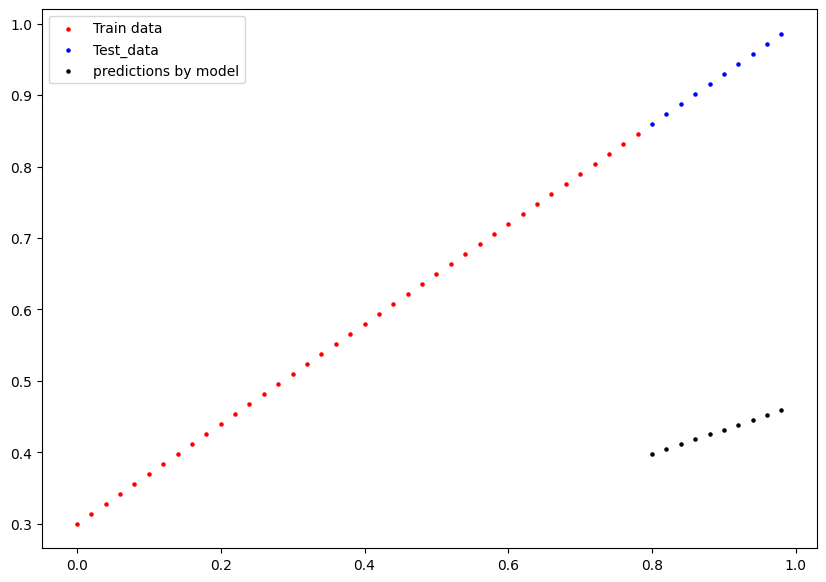

In [ ]:
#cheaking the model
with torch.inference_mode():
  y_pred=model_0(X_test)
  y_pred
  plotting(predictions=y_pred)

In [ ]:
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [ ]:
epoch=1
torch.manual_seed(42)
for i in range(epoch):
  model_0.train()

  y_pred=model_0(X_train)
  loss=loss_fn(y_pred,Y_train)
  print(f"loss is : {loss}")
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  model_0.eval() # turn off the gradient



loss is : 0.05845819041132927


In [ ]:
with torch.inference_mode():
  y_pred_new=model_0(X_test)

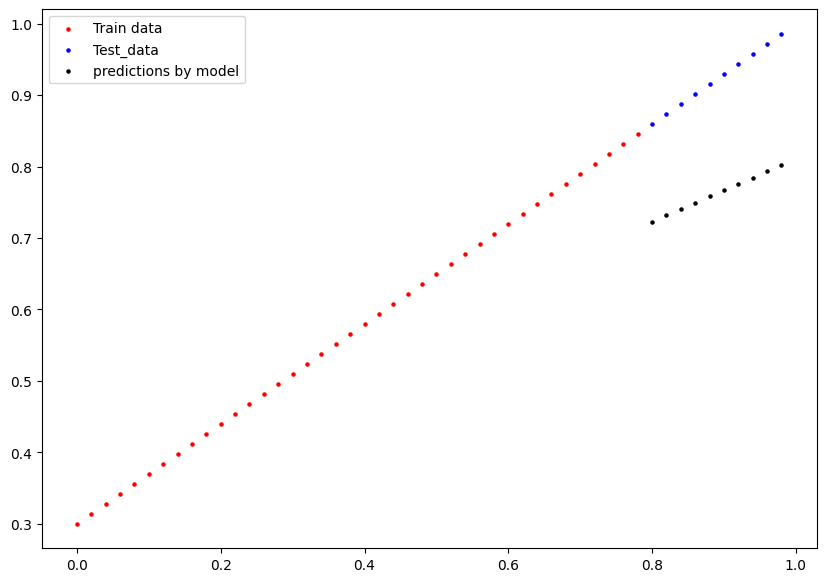

In [ ]:
plotting(predictions=y_pred_new)

In [ ]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3406])), ('bias', tensor([0.1388]))])

In [ ]:
weight,bias

(0.7, 0.3)